<a href="https://colab.research.google.com/github/silviamoya/03MIAR-Algoritmos-Optimizacion/blob/main/Practicas_guiadas/Algoritmos_AG3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG3 - Actividad Guiada 3
Nombre: Silvia Moya Botella <br>
Link:   https://colab.research.google.com/drive/1qbAQ2sVoHt0hnsW7ijzWQnnccoPh9DOZ?usp=sharing <br>
Github: https://github.com/silviamoya/03MIAR-Algoritmos-Optimizacion/blob/main/Practicas_guiadas/Algoritmos_AG2_actualizado.ipynb
<br>


#Carga de librerias

In [1]:
!pip install requests    #Hacer llamadas http a paginas de la red
!pip install tsplib95    #Modulo para las instancias del problema del TSP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.3.0
    Uninstalling wrapt-2.3.0:
      Successfully uninstalled wrapt-2.3.0
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
momepy 0.11.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
bigframes 2.42.0 re

#Carga de los datos del problema

In [2]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
# urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
# !gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#URL alternativa
# file = "swiss42.tsp" ;
# urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)




In [3]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [4]:
Aristas

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),


In [5]:
#Comprobar el nombre del problema
print(problem.name)

#Comprobar el número de Nodos
print(len(Nodos))

#Comprobar los 10 primeros Nodos
print(Nodos[:10])

#Comprobar las 10 primeras Aristas
print(Aristas[:10])

swiss42
42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]



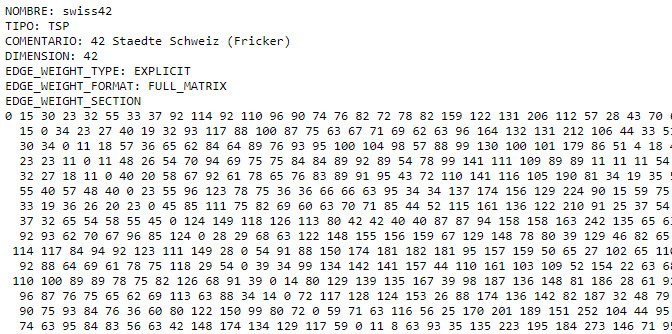

In [6]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

#Funcionas basicas


In [9]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(4874,
 [0,
  8,
  12,
  9,
  30,
  24,
  16,
  41,
  28,
  33,
  38,
  25,
  13,
  20,
  39,
  21,
  6,
  40,
  1,
  5,
  17,
  22,
  7,
  18,
  34,
  11,
  29,
  32,
  14,
  10,
  37,
  31,
  36,
  2,
  27,
  19,
  23,
  26,
  4,
  35,
  15,
  3])

#BUSQUEDA ALEATORIA

Mejor solución: [0, 3, 25, 22, 9, 5, 32, 1, 7, 21, 29, 39, 12, 41, 18, 13, 23, 40, 24, 11, 35, 31, 36, 37, 17, 14, 15, 19, 30, 34, 20, 8, 27, 2, 16, 6, 33, 28, 10, 4, 26, 38]
Distancia     : 3651


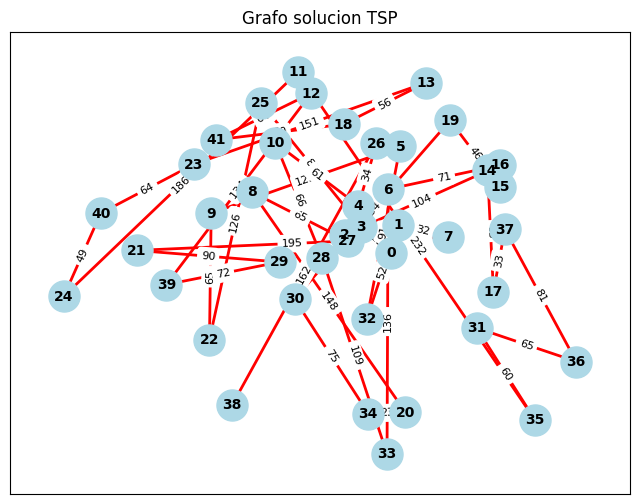

In [10]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 10000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

#BUSQUEDA LOCAL

In [11]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3651
Distancia Mejor Solucion Local: 3413


En la iteracion  31 , la mejor solución encontrada es: [0, 2, 28, 30, 39, 24, 40, 21, 32, 31, 17, 37, 15, 16, 19, 13, 12, 10, 29, 22, 38, 34, 33, 20, 35, 36, 14, 11, 25, 41, 23, 9, 8, 18, 26, 5, 7, 1, 6, 4, 3, 27]
Distancia     : 1843


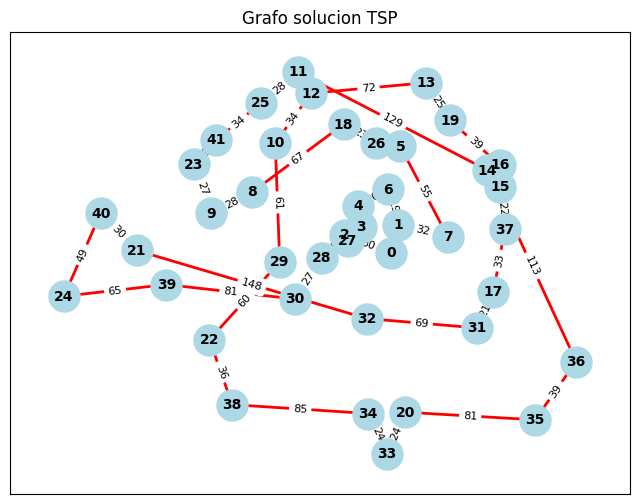

In [52]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(problem)

plot_tsp_solution(problem.edge_weights, sol)

## Mejora de la búsqueda local con multiarranque

La búsqueda local parte de una solución inicial aleatoria y va seleccionando soluciones vecinas mejores hasta alcanzar un mínimo local.

Uno de los principales inconvenientes de este método es que el resultado depende de la solución inicial utilizada. Diferentes soluciones iniciales pueden conducir a mínimos locales de distinta calidad.

Para reducir esta dependencia se va a implementar una estrategia de **Multiarranque**. Esta consiste en ejecutar varias veces la búsqueda local,utilizando en cada ejecución una solución inicial aleatoria diferente.

Finalmente, se compararán las soluciones obtenidas y se selecciona aquella que presenta la menor distancia.

De esta forma se exploran diferentes regiones del espacio de soluciones y aumenta la probabilidad de encontrar una solución de mayor calidad.

In [50]:
def busqueda_local_multiarranque(problem, num_arranques=20):

    mejor_solucion_global = None
    mejor_distancia_global = float("inf")

    resultados = []

    for arranque in range(num_arranques):

        # Ejecutamos una búsqueda local completa
        solucion = busqueda_local(problem)

        # Calculamos la distancia del mínimo local encontrado
        distancia = distancia_total(solucion, problem)

        # Guardamos el resultado para analizarlo posteriormente
        resultados.append(distancia)

        print("Arranque", arranque + 1, "- Distancia:", distancia)

        # Si mejora la mejor solución encontrada hasta ahora, la guardamos
        if distancia < mejor_distancia_global:

            mejor_solucion_global = solucion
            mejor_distancia_global = distancia

            print("   --> Nueva mejor solución global:",
                  mejor_distancia_global)

    return mejor_solucion_global, mejor_distancia_global, resultados

### Ejecución del algoritmo Multiarranque

Se realizan 20 ejecuciones independientes de la búsqueda local. Cada ejecución
comienza desde una solución inicial aleatoria diferente.

Un mayor número de arranques permite explorar más regiones del espacio de
soluciones, aunque también aumenta el tiempo de ejecución.

In [55]:
sol_multi, distancia_multi, resultados = busqueda_local_multiarranque(
    problem,
    num_arranques=20
)

print("\n====================================")
print("MEJOR RESULTADO MULTIARRANQUE")
print("====================================")

print("Mejor solución:")
print(sol_multi)

print("\nMejor distancia:", distancia_multi)

En la iteracion  33 , la mejor solución encontrada es: [0, 32, 20, 33, 34, 28, 2, 27, 1, 7, 17, 36, 35, 31, 30, 29, 23, 41, 10, 6, 37, 15, 16, 14, 19, 13, 5, 26, 9, 39, 21, 40, 24, 38, 22, 8, 25, 11, 12, 18, 4, 3]
Distancia     : 1770
Arranque 1 - Distancia: 1770
   --> Nueva mejor solución global: 1770
En la iteracion  32 , la mejor solución encontrada es: [0, 27, 9, 40, 24, 21, 39, 22, 38, 33, 35, 36, 37, 1, 28, 30, 29, 8, 23, 41, 25, 11, 12, 10, 2, 3, 4, 6, 5, 26, 18, 13, 19, 14, 16, 15, 32, 34, 20, 31, 17, 7]
Distancia     : 1714
Arranque 2 - Distancia: 1714
   --> Nueva mejor solución global: 1714
En la iteracion  29 , la mejor solución encontrada es: [0, 6, 26, 5, 14, 15, 16, 19, 13, 12, 11, 25, 41, 10, 18, 4, 1, 7, 17, 31, 20, 38, 22, 39, 8, 37, 36, 35, 33, 21, 24, 40, 23, 9, 29, 30, 34, 32, 28, 2, 27, 3]
Distancia     : 1969
Arranque 3 - Distancia: 1969
En la iteracion  31 , la mejor solución encontrada es: [0, 32, 34, 30, 29, 8, 10, 25, 41, 23, 9, 21, 40, 24, 39, 22, 38, 33, 2

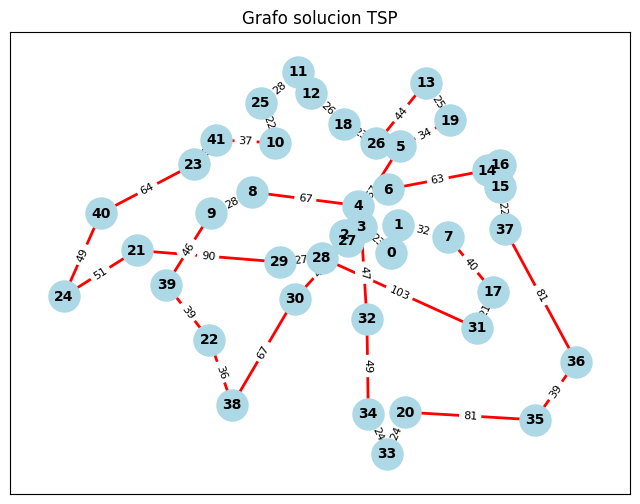

In [56]:
plot_tsp_solution(problem.edge_weights, sol_multi)

#SIMULATED ANNEALING


In [44]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 32, 34, 33, 3, 6, 5, 13, 14, 37, 15, 16, 19, 1, 7, 27, 2, 28, 30, 20, 35, 36, 31, 17, 26, 11, 12, 10, 23, 40, 24, 21, 39, 9, 22, 38, 29, 8, 41, 25, 18, 4]
con una distancia total de 1900


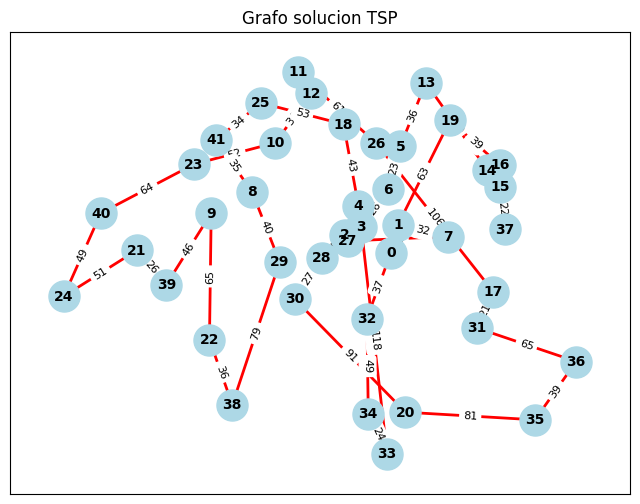

In [48]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

## Mejora del Recocido Simulado: selección de vecinos

En la implementación original del Recocido Simulado se genera un único vecino
completamente aleatorio en cada iteración, intercambiando dos nodos de la solución.

Esta estrategia tiene el inconveniente de que el vecino seleccionado puede ser
de muy baja calidad, aunque existan otros vecinos cercanos mucho mejores.

Para mejorar la selección de vecinos se propone generar varios vecinos aleatorios en cada iteración y seleccionar entre ellos el que presente la menor distancia.

De esta forma se mantiene la componente aleatoria del Recocido Simulado, pero
se realiza una selección más informada del vecino que será evaluado por el
algoritmo.

In [69]:
# se generan 10 vecinos aleatorios y se selecciona el mejor

def genera_mejor_vecino_aleatorio(solucion, problem, num_vecinos=10):

    mejor_vecino = None
    mejor_distancia = float("inf")

    for _ in range(num_vecinos):

        # Generamos un vecino usando la función original del profesor
        vecino = genera_vecina_aleatorio(solucion)

        # Calculamos su distancia
        distancia_vecino = distancia_total(vecino, problem)

        # Guardamos el mejor de los vecinos generados
        if distancia_vecino < mejor_distancia:
            mejor_vecino = vecino
            mejor_distancia = distancia_vecino

    return mejor_vecino

In [70]:
def recocido_simulado_mejorado(problem, TEMPERATURA, num_vecinos=10):

    solucion_referencia = crear_solucion(Nodos)
    distancia_referencia = distancia_total(solucion_referencia, problem)

    mejor_solucion = []
    mejor_distancia = 10e100

    while TEMPERATURA > .0001:

        # en lugar de generar un único vecino aleatorio,
        # generamos varios y seleccionamos el mejor
        vecino = genera_mejor_vecino_aleatorio(
            solucion_referencia,
            problem,
            num_vecinos
        )

        distancia_vecina = distancia_total(vecino, problem)

        # Si es la mejor solución encontrada, se guarda
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecino
            mejor_distancia = distancia_vecina

        # Se acepta si mejora o según la probabilidad del recocido simulado
        if (
            distancia_vecina < distancia_referencia
            or probabilidad(
                TEMPERATURA,
                abs(distancia_referencia - distancia_vecina)
            )
        ):
            solucion_referencia = vecino
            distancia_referencia = distancia_vecina

        # Bajamos la temperatura
        TEMPERATURA = bajar_temperatura(TEMPERATURA)

    print("La mejor solución encontrada es ", mejor_solucion)
    print("con una distancia total de ", mejor_distancia)

    return mejor_solucion

La mejor solución encontrada es  [0, 31, 35, 36, 17, 7, 1, 6, 14, 37, 15, 16, 19, 13, 12, 11, 25, 41, 23, 9, 40, 24, 21, 39, 22, 38, 30, 29, 8, 10, 18, 26, 5, 4, 28, 34, 33, 20, 32, 27, 2, 3]
con una distancia total de  1556


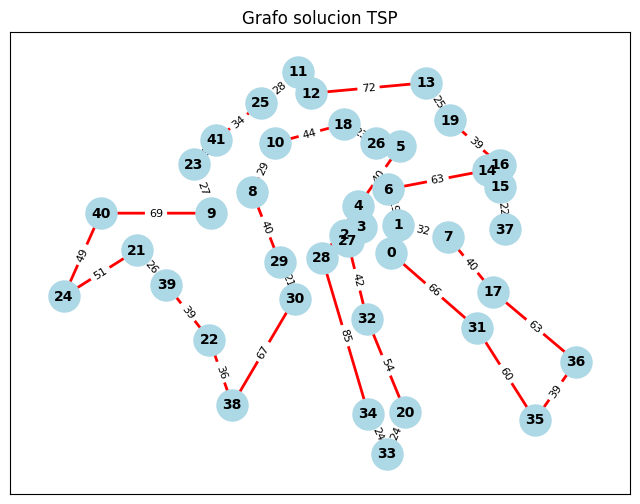

In [71]:
sol_mejorada = recocido_simulado_mejorado(
    problem,
    10000000,
    num_vecinos=10
)

plot_tsp_solution(
    problem.edge_weights,
    sol_mejorada
)